# 神経突起の成長モデル

Julia 版 neurite-growth-model_jl.ipynb を参考に Python へ移植したノートブックです。


## 神経突起の木構造

tree_info の各要素は [親分節の index, 遠心性位数, 末端分節かどうか]、seg_vec の各要素は [長さ, 角度] です。Python 版では index を 0 始まりにしています。


In [6]:
import math
import time

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from tqdm.notebook import tqdm

plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.family"] = ["Meiryo", "Yu Gothic", "DejaVu Sans"]


In [7]:
tree_info_eg = [
    [0, 0, 0], [0, 0, 0], [1, 1, 0], [1, 1, 0], [2, 2, 1],
    [2, 2, 1], [3, 2, 1], [3, 2, 1], [7, 2, 1], [8, 2, 1], [8, 2, 1],
]

seg_vec_eg = [
    [0.0, 0.0], [1.0, math.pi / 2], [math.sqrt(2), 3 * math.pi / 4], [math.sqrt(2), math.pi / 4],
    [math.sqrt(2) / 2, 3 * math.pi / 4], [math.sqrt(2) / 2, math.pi / 4],
    [math.sqrt(2) / 2, 3 * math.pi / 4], [math.sqrt(2) / 2, math.pi / 4],
    [math.sqrt(2) / 2, math.pi / 4], [math.sqrt(2) / 2, 3 * math.pi / 4], [math.sqrt(2) / 2, math.pi / 4],
]


木構造を描画するための関数を作成します。segments_lines は tree_info と seg_vec から節点位置 pos と各分節の両端点 lines を返します。


In [8]:
def segments_lines(tree_info, seg_vec, init_pos=None):
    num_segments = len(tree_info)
    pos = np.zeros((num_segments, 2), dtype=float)
    if init_pos is not None:
        pos[0] = init_pos

    for j, (parent, _, _) in enumerate(tree_info):
        length, angle = seg_vec[j]
        pos[j] = pos[parent] + length * np.array([math.cos(angle), math.sin(angle)])

    lines = []
    for j, (parent, _, _) in enumerate(tree_info):
        x1, y1 = pos[parent]
        x2, y2 = pos[j]
        lines.append([(x1, y1), (x2, y2)])
    return lines, pos


In [9]:
lines_eg, _ = segments_lines(tree_info_eg, seg_vec_eg)


木構造を描画してみましょう。各部位の説明を加えています。


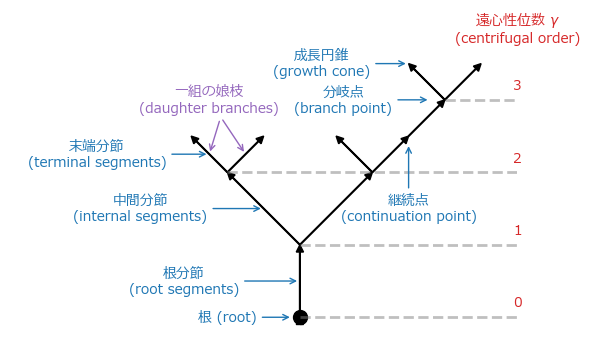

In [10]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
for line in lines_eg:
    (x, y), (x2, y2) = line
    ax.arrow(x, y, x2 - x, y2 - y, width=0.01, head_width=0.1, head_length=0.1, length_includes_head=True, color="k")
ax.scatter(0, 0, s=100, color="k")

ax.text(3, 4, "遠心性位数 $\\gamma$\n(centrifugal order)", size=10, color="tab:red", ha="center", va="center")
for i, y in enumerate([0, 0, -1, 2]):
    ax.hlines(i, y, 3, color="gray", linestyle="dashed", linewidth=2, alpha=0.5)
    ax.text(3, i + 0.2, str(i), size=10, color="tab:red", ha="center", va="center")

arrowprops = {"arrowstyle": "->", "color": "tab:blue"}
ax.annotate("根 (root)", xy=(-0.1, 0), xytext=(-1.0, 0), size=10, color="tab:blue", ha="center", va="center", arrowprops=arrowprops)
ax.annotate("根分節\n(root segments)", xy=(0, 0.5), xytext=(-1.6, 0.5), size=10, color="tab:blue", ha="center", va="center", arrowprops=arrowprops)
ax.annotate("中間分節\n(internal segments)", xy=(-0.5, 1.5), xytext=(-2.2, 1.5), size=10, color="tab:blue", ha="center", va="center", arrowprops=arrowprops)
ax.annotate("末端分節\n(terminal segments)", xy=(-1.25, 2.25), xytext=(-2.8, 2.25), size=10, color="tab:blue", ha="center", va="center", arrowprops=arrowprops)
ax.annotate("分岐点\n(branch point)", xy=(1.8, 3), xytext=(0.6, 3), size=10, color="tab:blue", ha="center", va="center", arrowprops=arrowprops)
ax.annotate("成長円錐\n(growth cone)", xy=(1.5, 3.5), xytext=(0.3, 3.5), size=10, color="tab:blue", ha="center", va="center", arrowprops=arrowprops)
ax.annotate("継続点\n(continuation point)", xy=(1.5, 2.4), xytext=(1.5, 1.5), size=10, color="tab:blue", ha="center", va="center", arrowprops=arrowprops)
ax.annotate("一組の娘枝\n(daughter branches)", xy=(-0.75, 2.25), xytext=(-1.25, 3), size=10, color="tab:purple", ha="center", va="center", arrowprops={"arrowstyle": "->", "color": "tab:purple"})
ax.annotate("", xy=(-1.25, 2.25), xytext=(-1.1, 2.74), ha="center", va="center", arrowprops={"arrowstyle": "->", "color": "tab:purple"})

ax.set_xlim(-4, 3)
ax.set_ylim(-0.3, 4)
ax.axis("off")
ax.set_aspect("equal")
fig.tight_layout()


## Van Peltモデル

時刻 t、遠心性位数 gamma、末端分節数 n などから分岐確率を計算します。


In [11]:
def branching_prob(t, dt, gamma, n, C, B_inf, E, S, tau):
    return (n ** (-E)) * B_inf * math.exp(-t / tau) * (math.exp(dt / tau) - 1) * (2 ** (-S * gamma)) / C


### 伸長 (elongation)

分岐しなかった末端分節は伸長します。確率的に向きを変えながら新しい分節を追加するか、既存の末端分節の長さを伸ばします。


In [12]:
def neurite_growth_model(
    tree_info_init,
    seg_vec_init,
    nt,
    dt,
    B_inf,
    E,
    S,
    tau,
    mu_e,
    sigma_e,
    turn_rate=5,
    max_branch_angle=0.1 * math.pi,
    max_turn_angle=5e-3 * math.pi,
    history_num=3,
    rng=None,
):
    
    tree_info = [row.copy() for row in tree_info_init]
    seg_vec = [row.copy() for row in seg_vec_init]
    num_branching = 0

    if history_num > 1:
        tree_info_history = []
        seg_vec_history = []
        history_timing = np.linspace(1, nt, history_num + 1, dtype=int)[1:]

    for tt in tqdm(range(1, nt + 1)):
        t = tt * dt
        terminal_segments = [row for row in tree_info if row[2] == 1]
        n = float(len(terminal_segments))
        if n == 0:
            continue
        C = sum(2 ** (-S * row[1]) for row in terminal_segments) / n

        current_num_segments = len(tree_info)
        for j in range(current_num_segments):
            _, gamma, is_terminal = tree_info[j]
            if is_terminal != 1:
                continue

            p_branch = branching_prob(t, dt, gamma, n, C, B_inf, E, S, tau)
            if p_branch > rng.random():
                num_branching += 1
                branch_lens = (mu_e + rng.normal(size=2) * sigma_e) * dt
                branch_angles = np.array([1, -1]) * rng.uniform(0, max_branch_angle, size=2)
                for k in range(2):
                    tree_info.append([j, gamma + 1, 1])
                    seg_vec.append([float(branch_lens[k]), seg_vec[j][1] + float(branch_angles[k])])
                tree_info[j][2] = 0
            else:
                delta_len = (mu_e + rng.normal() * sigma_e) * dt
                p_turn = turn_rate * delta_len
                if p_turn > rng.random():
                    tree_info.append([j, gamma, 1])
                    seg_angle = seg_vec[j][1] + rng.uniform(-max_turn_angle, max_turn_angle)
                    seg_vec.append([float(delta_len), float(seg_angle)])
                    tree_info[j][2] = 0
                else:
                    seg_vec[j][0] += float(delta_len)

        if history_num > 1 and tt in history_timing:
            tree_info_history.append([row.copy() for row in tree_info])
            seg_vec_history.append([row.copy() for row in seg_vec])

    print(f"Num. branching: {num_branching}")
    if history_num > 1:
        return tree_info_history, seg_vec_history
    return tree_info, seg_vec


パラメータを設定します。Julia 版と同じ値を使います。


In [13]:
B_inf = 13.2
E = 0.319
S = -0.205
tau = 1_681_541
mu_e = 2.14e-4
sigma_e = 3.98e-4

turn_rate = 3
max_branch_angle = 0.25 * math.pi
max_turn_angle = 1e-2 * math.pi

T = 18 * 24 * 60 * 60  # duration of growth; convert 18 days to sec
dt = 200  # sec
nt = round(T / dt)


シミュレーションを実行します。


In [14]:
history_num = 3
init_branch_num = 2

tree_info_init = [[0, 0, 0]]
seg_vec_init = [[0.0, 0.0]]

rng = np.random.default_rng(0)
for i in range(init_branch_num):
    tree_info_init.append([0, 0, 1])
    seg_vec_init.append([(mu_e + rng.normal() * sigma_e) * dt, i / init_branch_num * 2 * math.pi + 1e-2 * rng.normal()])

start = time.perf_counter()
tree_info_history, seg_vec_history = neurite_growth_model(
    tree_info_init,
    seg_vec_init,
    nt,
    dt,
    B_inf,
    E,
    S,
    tau,
    mu_e,
    sigma_e,
    turn_rate,
    max_branch_angle,
    max_turn_angle,
    history_num,
    rng=rng,
)
print(f"Elapsed: {time.perf_counter() - start:.2f} sec")


  0%|          | 0/7776 [00:00<?, ?it/s]

Num. branching: 99
Elapsed: 17.12 sec


結果を表示します。初めの神経突起の数を 2 にしていてもそれ以上出ているように見えるのは、最初期に分岐しているためです。


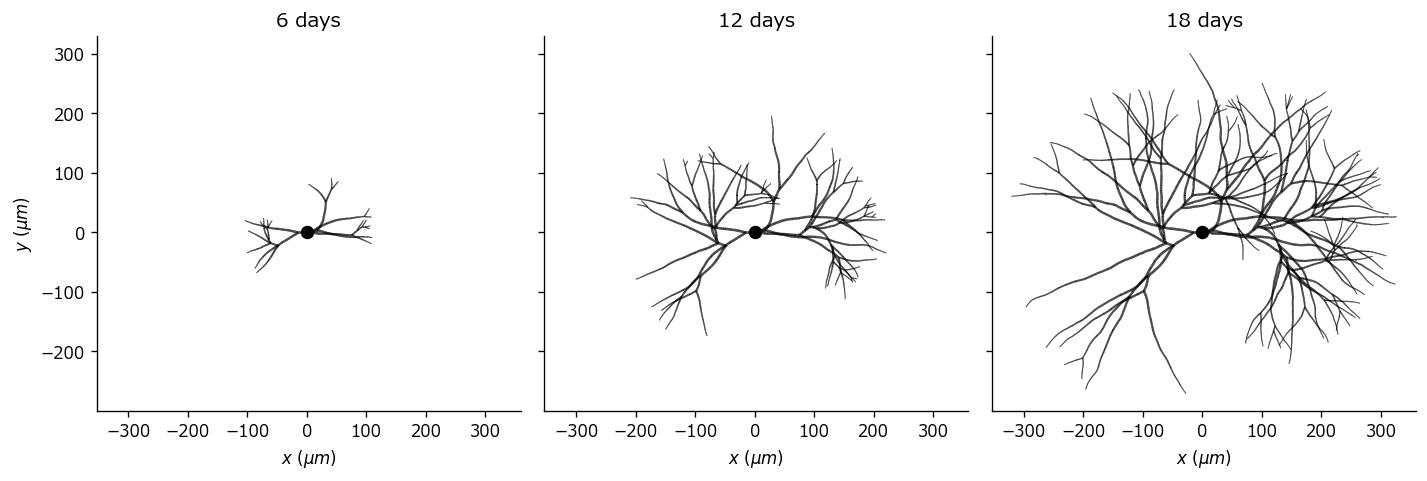

In [15]:
maxwidth, minwidth = 1.5, 0.5
days_range = np.linspace(1, 18, history_num + 1, dtype=int)[1:]

fig, axes = plt.subplots(1, history_num, sharex=True, sharey=True, figsize=(4 * history_num, 4), dpi=120)
if history_num == 1:
    axes = [axes]

for ax, tree_info, seg_vec, days in zip(axes, tree_info_history, seg_vec_history, days_range):
    lines, _ = segments_lines(tree_info, seg_vec)
    linewidths = np.linspace(maxwidth, minwidth, len(lines))
    line_segments = LineCollection(lines, linewidths=linewidths, color="k")
    ax.add_collection(line_segments)
    ax.scatter(0, 0, s=50, color="k")
    ax.set_xlabel(r"$x\ (\mu m)$")
    ax.set_ylabel(r"$y\ (\mu m)$")
    ax.set_aspect("equal")
    ax.set_title(f"{days} days")
    ax.autoscale()
    ax.label_outer()

fig.tight_layout()


対称性の破れを考慮していないので、円形に成長しています。


## 参考文献

Julia 版ノートブックの参考文献記法を引き継いでいます。
